In [ ]:
import numpy as np
from scipy.optimize import curve_fit
from astropy.io import fits
import matplotlib.pyplot as plt
import os
from itertools import product
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def model_spectrum(lam, tau0, delta_lambda, S, mu):
    tau_lam = tau0 * np.exp(-0.5*((lam-mu)**2) / delta_lambda**2)
    return f_o_l_TR* np.exp(-tau_lam) + S * (1 - np.exp(-tau_lam))

In [3]:
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)

In [8]:
image_half_side = 1100  # The half side length of the cropped image. Unit: pixels.
psr = 1.0436  # Pixel spatial resolution. Unit: arcsec per pixel.

TR_center = [350,
             -370]  # The center of the target region. Relative to the center of the solar disk. [relative_x , relative_y]. Unit: arcsec.
TR_half_side = 120  # The half side length of the target region. Unit: arcsec.
TR_width = 140
TR_height = 140

ha_left_index = 30  # The index of the left  border of Ha line. Minimum: 30
ha_right_index = 117  # The index of the right border of Ha line. Maximum: 117
TR_center_x = TR_center[0]
TR_center_y = TR_center[1]
input_fitsfile_ha_1 = rsm[1]
cx_ha = float(input_fitsfile_ha_1.header['CRPIX1'])  # Unit: pixels.
cy_ha = float(input_fitsfile_ha_1.header['CRPIX2'])  # Unit: pixels.
r_ha = float(input_fitsfile_ha_1.header['R_SUN'])  # Unit: pixels.
data_ha_TR = input_fitsfile_ha_1.data[:, int(round(cy_ha + TR_center_y / psr - TR_height / psr)):int(
        round(cy_ha + TR_center_y / psr + TR_height / psr)) + 1,
                 int(round(cx_ha + TR_center_x / psr - TR_width / psr)):int(
                     round(cx_ha + TR_center_x / psr + TR_width / psr)) + 1]
data_hac_TR_image = np.array(data_ha_TR[68, :, :], dtype=np.float64) # 复制第 68 层数据
for i in range(1, 41):  # 从 1 到 10 进行累加
    data_hac_TR_image += data_ha_TR[68 - i, :, :]
    data_hac_TR_image += data_ha_TR[68 + i, :, :]
data_hac_TR_image /= 120
high_flux_indices = np.where(data_hac_TR_image >= 520)
indices = np.where(input_fitsfile_ha_1.data > 0)
low_flux_indices = np.where((data_hac_TR_image < 520) & (data_hac_TR_image > 0))
i_indices, j_indices = low_flux_indices
k_indices, l_indices = high_flux_indices
f_o_l_TR = data_ha_TR[:, k_indices, l_indices].mean(axis=1)
f_d_l_TR = data_ha_TR[:, i_indices, j_indices].mean(axis=1)

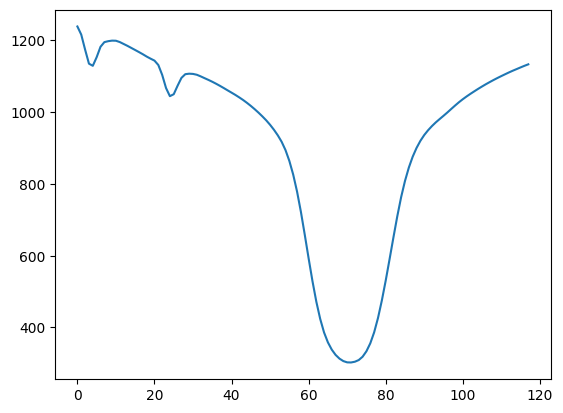

In [5]:
plt.plot(f_o_l_TR)

In [9]:
wavelength_point_list_ha_t1 = np.array(
        [input_fitsfile_ha_1.header['CRVAL3'] + i * input_fitsfile_ha_1.header['CDELT3'] for i in range(118)])
x_fit = np.array(wavelength_point_list_ha_t1) - 6562.8

Optimal τ₀: 0.7691261012890132
Optimal Δλ: 1.1999999999999997
Optimal S: 417.3078324320923
Optimal mu: -0.37633877721148246


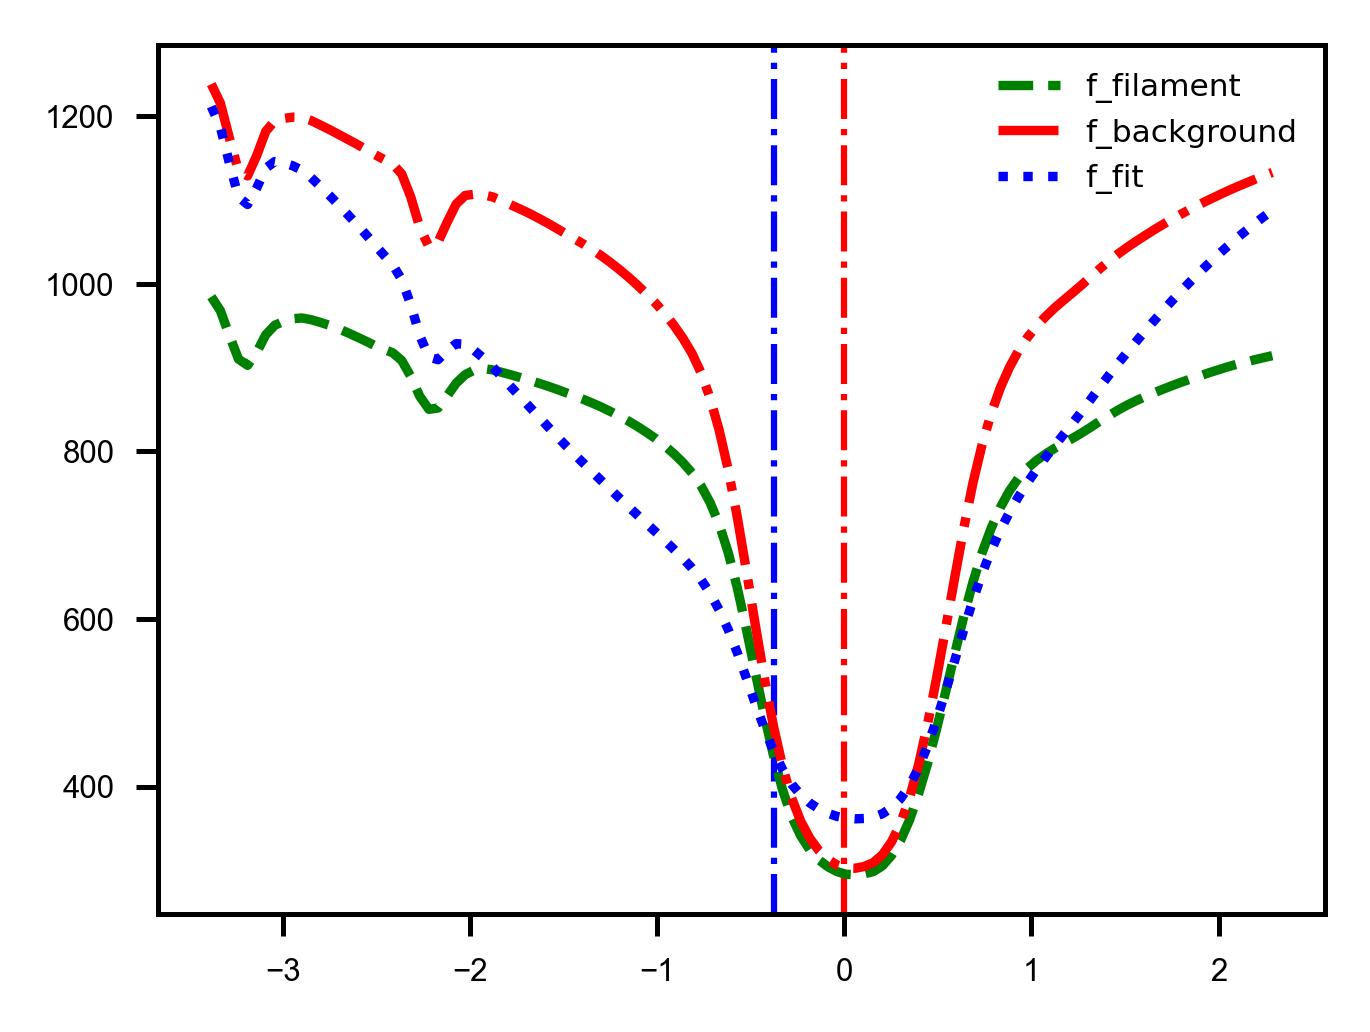

In [10]:
initial_tau0 = 5
initial_delta_lambda = 0.5
initial_S = 100
initial_mu = -1
popt, pcov = curve_fit(model_spectrum, (np.array(wavelength_point_list_ha_t1) - 6562.8), f_d_l_TR ,
                    p0=[initial_tau0, initial_delta_lambda, initial_S,initial_mu], bounds = ([0.3,0.1, 0.001,-3],[10,1.2,500,-0.01]),maxfev = 2000)

# 输出最优参数
tau0_opt, delta_lambda_opt, S_opt, mu_opt = popt

print("Optimal τ₀:", tau0_opt)
print("Optimal Δλ:", delta_lambda_opt)
print("Optimal S:", S_opt)
print("Optimal mu:", mu_opt)

plt.figure(figsize=(3.3464567, 3.3464567 * 0.75), dpi=450)
#plt.suptitle(start_time_str + ' UT', fontsize=5, fontname='Arial')
plt.yticks(fontsize=5, fontname='Arial')
plt.xticks([-3.0,-2.0,-1.0,0.0,1.0,2.0], fontsize=5, fontname='Arial')
plt.axvline(0, linewidth=1, linestyle='-.', color='red', zorder=0.1)
plt.axvline(mu_opt, linewidth=1, linestyle='-.', color='blue', zorder=0.1)
plt.plot(np.array(wavelength_point_list_ha_t1) - 6562.8, f_d_l_TR, label="f_filament",
        linestyle='--', color='green', zorder=0.2)
plt.plot(np.array(wavelength_point_list_ha_t1) - 6562.8, f_o_l_TR, label="f_background", linestyle='-.',
        color='red', zorder=0.2)
plt.plot(x_fit, model_spectrum(x_fit, tau0_opt, delta_lambda_opt, S_opt, mu_opt), label="f_fit", linestyle=':',
    color='blue', zorder=0.2)
plt.legend(loc='upper right', fontsize=5, frameon=False)
#plt.savefig(output_dir_figures + '/mass/' + input_fitsfilename_ha[:-5] + '_mass.pdf', dpi=450, bbox_inches='tight')
plt.show()